In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 
  
# metadata 
print(car_evaluation.metadata) 
  
# variable information 
print(car_evaluation.variables) 


{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

In [4]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()
y_encoded = y.copy()


# because we are working with categorical data
le_dict = {}
for column in X.columns:
    le = LabelEncoder()
    X_encoded[column] = le.fit_transform(X[column])
    le_dict[column] = le

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)


/home/sofijatasevska/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/home/sofijatasevska/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sofijatasevska/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sofijatasevska/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

              precision    recall  f1-score   support

           0       0.84      0.64      0.73        83
           1       0.00      0.00      0.00        11
           2       0.92      0.98      0.95       235
           3       0.52      1.00      0.68        17

    accuracy                           0.87       346
   macro avg       0.57      0.66      0.59       346
weighted avg       0.85      0.87      0.85       346



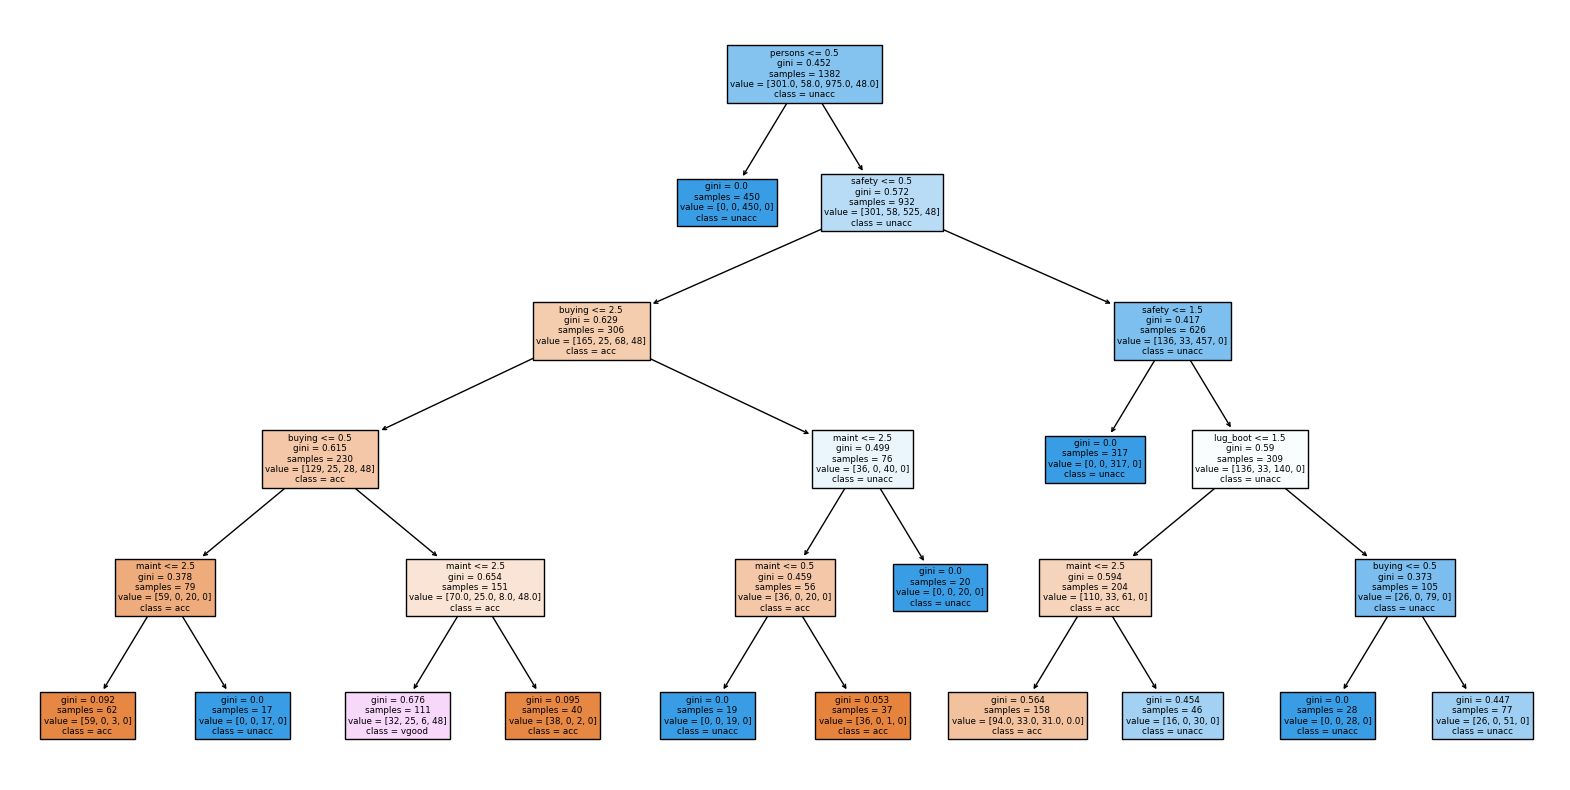

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, criterion='gini')
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print(classification_report(y_test, y_pred_dt))

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=le_target.classes_, filled=True)
plt.show()


              precision    recall  f1-score   support

           0       0.99      0.90      0.94        83
           1       0.65      1.00      0.79        11
           2       0.99      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.98       346



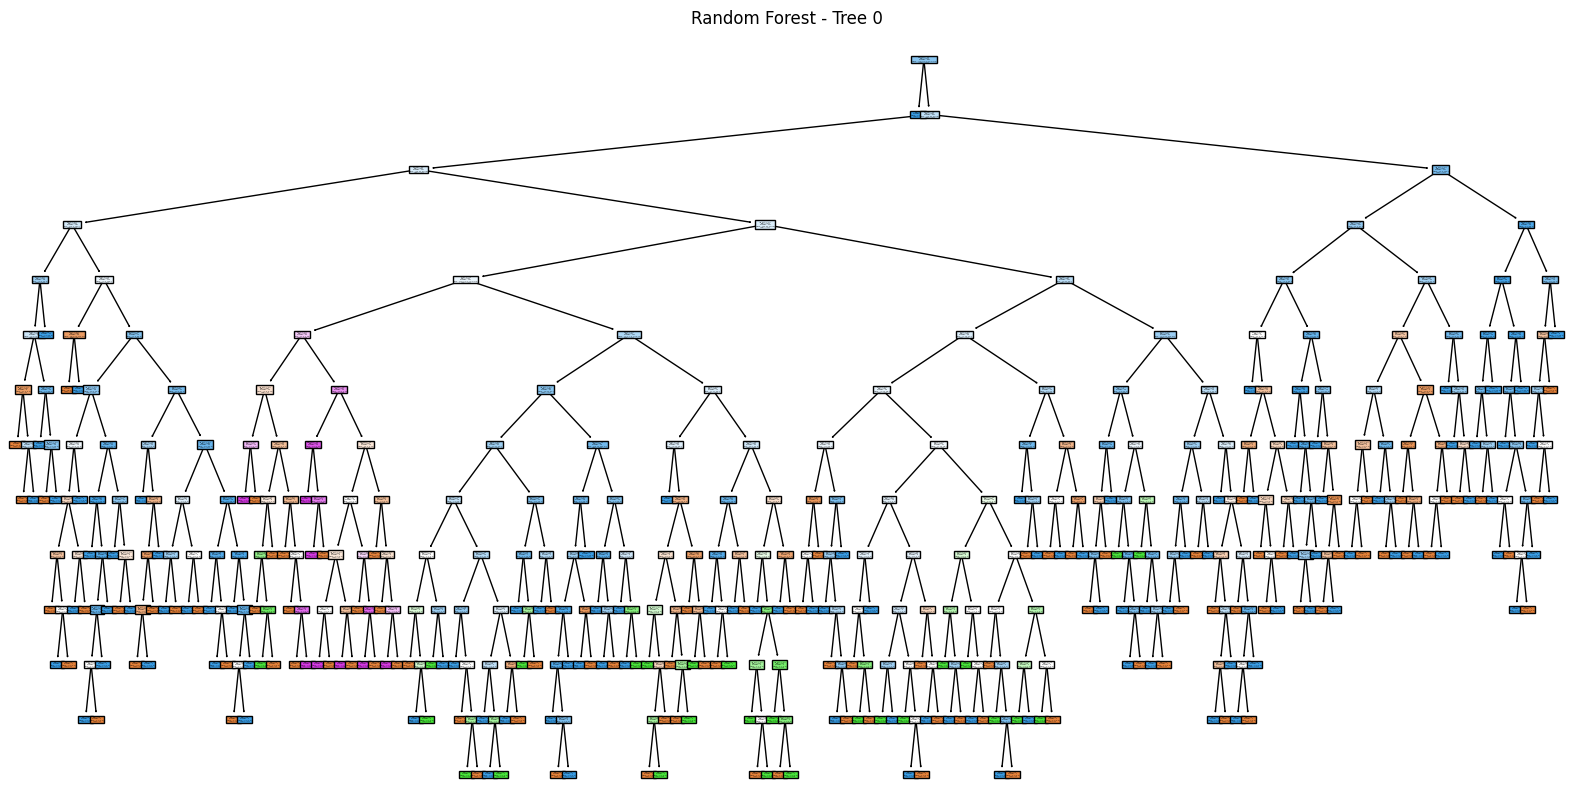

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt', bootstrap=True, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0], feature_names=X.columns, class_names=le_target.classes_, filled=True)
plt.title("Random Forest - Tree 0")
plt.show()



              precision    recall  f1-score   support

           0       0.98      0.95      0.96        83
           1       0.79      1.00      0.88        11
           2       0.99      1.00      0.99       235
           3       1.00      0.82      0.90        17

    accuracy                           0.98       346
   macro avg       0.94      0.94      0.93       346
weighted avg       0.98      0.98      0.98       346



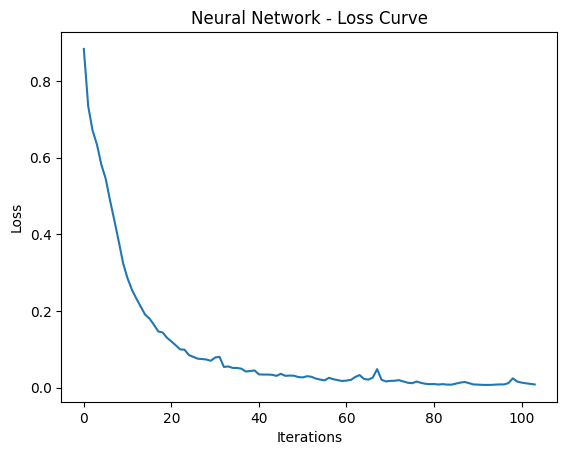

In [9]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(50, 25), activation='relu', learning_rate_init=0.01, max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

print(classification_report(y_test, y_pred_nn))


plt.plot(nn_model.loss_curve_)
plt.title("Neural Network - Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()



In [10]:
from sklearn.metrics import classification_report

print("Decision Tree:")
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

print("Neural Network:")
print(classification_report(y_test, y_pred_nn, target_names=le_target.classes_))


Decision Tree:
              precision    recall  f1-score   support

         acc       0.84      0.64      0.73        83
        good       0.00      0.00      0.00        11
       unacc       0.92      0.98      0.95       235
       vgood       0.52      1.00      0.68        17

    accuracy                           0.87       346
   macro avg       0.57      0.66      0.59       346
weighted avg       0.85      0.87      0.85       346

Random Forest:
              precision    recall  f1-score   support

         acc       0.99      0.90      0.94        83
        good       0.65      1.00      0.79        11
       unacc       0.99      1.00      1.00       235
       vgood       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.98       346

Neural Network:
              precision    recall  f1-score   support

         acc       0.98      

/home/sofijatasevska/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sofijatasevska/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/sofijatasevska/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)